<a href="https://colab.research.google.com/github/pachterlab/cellmender/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellmender import denoise_count_matrix
# except ImportError:
#     print("cellmender not found, installing...")
#     !pip install -U -q cellmender[analysis]

In [2]:
import os
import anndata as ad
import scanpy as sc
from cellmender import denoise_count_matrix
import cellmender.utils as cm_utils

cellmender_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellmender"

/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


# Compare CellBender vs. cellmender

Some datasets of use:
- tiny mouse heart dataset from CellBender (CellBender/examples/remove_background/generate_tiny_10x_dataset.py): https://www.10xgenomics.com/resources/datasets/10-k-heart-cells-from-an-e-18-mouse-v-3-chemistry-3-standard-3-0-0 

- pbmc8k: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0
  - see run configuration on page 13 (bottom left) of the [Cellbender manuscript](https://doi.org/10.1038/s41592-023-01943-7)
- hgmm12k: Human-mouse mixture (CellBender Fig5): https://support.10xgenomics.com/single-cell-gene-expression/datasets/2.1.0/hgmm_12k?

In [3]:
dataset_name = "pbmc8k"  # options: pbmc8k
iterations = 4
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
scar_env = "/home/jrich/miniconda3/envs/scar_gpu"
use_cuda = True
threads = 8

In [4]:
data_dir = os.path.join(cellmender_dir, "notebooks", "data", dataset_name, "idempotency")
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellmender_dir, "notebooks", "output", dataset_name, "idempotency")
os.makedirs(out_dir, exist_ok=True)

if dataset_name == "pbmc8k":
    adata_path_raw = f"{data_dir}/pbmc8k_raw_gene_bc_matrices_h5.h5"
    sequencing_technology = "10XV2"
    model_pkl = "Immune_All_High.pkl"  # path to celltypist model pkl file
    expected_cells = 8381

    if not os.path.exists(adata_path_raw):
        !wget -O {adata_path_raw} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5

    matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
    os.makedirs(matrix_tar_files_dir, exist_ok=True)
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "GRCh38")
    if not os.path.exists(raw_tar_file_dir):
        raw_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_raw_gene_bc_matrices.tar.gz")
        !wget -O {raw_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices.tar.gz
        !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
    if not os.path.exists(filtered_tar_file_dir):
        filtered_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_filtered_gene_bc_matrices.tar.gz")
        !wget -O {filtered_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_filtered_gene_bc_matrices.tar.gz
        !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}
else:
    raise ValueError(f"Dataset name {dataset_name} not recognized.")

min_genes = 0
min_cells = 0
umi_top_percentile_to_remove = 5
unique_genes_top_percentile_to_remove = 5
mt_gene_percentile_to_remove = 10
max_mt_percentage = None
n_top_genes = 2000
n_pcs = 25
n_neighbors = 20
leiden_resolution = 1.0

--2025-12-04 15:03:13--  https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 2606:4700::6812:1ad, 2606:4700::6812:ad, 104.18.1.173, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|2606:4700::6812:1ad|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 32549555 (31M) [binary/octet-stream]
Saving to: ‘/Users/mcaskey/Desktop/cellmender/notebooks/data/pbmc8k/idempotency/pbmc8k_raw_gene_bc_matrices_h5.h5’

/Users/mcaskey/Desk 100%[===================>]  31.04M  21.0MB/s    in 1.5s    

2025-12-04 15:03:15 (21.0 MB/s) - ‘/Users/mcaskey/Desktop/cellmender/notebooks/data/pbmc8k/idempotency/pbmc8k_raw_gene_bc_matrices_h5.h5’ saved [32549555/32549555]

--2025-12-04 15:03:15--  https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices.tar.gz
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 2606:4700::6812:1ad, 2606:4700::6812:ad, 104.18.1.173, 

## Raw

In [5]:
adata_raw = cm_utils.load_adata(adata_path_raw, verbose=verbose)
adata_raw.var_names_make_unique()

adata_raw = cm_utils.infer_empty_droplets(adata_raw, method="threshold", expected_cells=expected_cells, verbose=verbose)  # adds adata.obs["is_empty"]

15:03:25 - INFO - Loading adata from '/Users/mcaskey/Desktop/cellmender/notebooks/data/pbmc8k/idempotency/pbmc8k_raw_gene_bc_matrices_h5.h5'
/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## cellmender

In [6]:
adata = adata_raw.copy()

adatas_cellmender = [adata]
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    adata_path_cellmender = os.path.join(data_dir, f"cellmender_iteration{it}.h5ad")
    cellmender_log_file = os.path.join(data_dir, f"cellmender_iteration{it}.log")
    if not os.path.exists(adata_path_cellmender) or overwrite:
        if "celltype" not in adata.obs.columns:
            adata = cm_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
        adata = denoise_count_matrix(adata, adata_out=adata_path_cellmender, max_iter=500, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellmender_log_file)
    else:
        adata = ad.read_h5ad(adata_path_cellmender)
    adata_filtered = adata[~adata.obs["is_empty"]].copy()
    adata_filtered.var_names_make_unique()
    adatas_cellmender.append(adata_filtered)

15:05:29 - INFO - Filtering empty droplets using column 'is_empty' in adata.obs. If this column is not present, it will be inferred using method 'celltypist' with umi_cutoff=None and expected_cells=8381.
15:05:29 - INFO - Running cell type annotation using CellTypist with model_pkl=Immune_All_High.pkl. This may take some time depending on the size of the dataset and the model used.
/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
📂 Storing models in /Users/mcaskey/.celltypist/data/models
⏩ Skipping [1/58]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/58]: Immune_All_High.pkl (file exists)
⏩ Skipping [3/58]: Adult_COVID19_PBMC.pkl (file exists)
⏩ Skipping [4/58]: Adult_CynomolgusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [5/58]: Adult_Human_MTG.pkl (file exists)
⏩ Skipping [6/58]: Adult_Human_PancreaticIsle

Iteration 1 / 4


15:05:29 - INFO - 'log1p' not found in adata_real.uns. Applying log1p transformation to adata_real.X and storing in 'log1p' layer.
🔬 Input data has 8381 cells and 33694 genes
🔗 Matching reference genes in the model
🧬 5656 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!
15:05:46 - INFO - Inferring gene ambient fractions.
15:05:46 - INFO - Added 'ambient_fraction' to adata.var.
15:05:46 - INFO - Inferring celltype profiles.
15:05:47 - INFO - Number of parameters in the cellmender model: 344,982 (alpha_i: 8,381, beta: 1, gamma_type: 67,048, p_k: 269,552)


Logging to /Users/mcaskey/Desktop/cellmender/notebooks/data/pbmc8k/idempotency/cellmender_iteration1.log


15:05:49 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
15:05:49 - INFO - Performing Sparse EM with 8 Numba thread(s)
15:05:51 - INFO - EM Iter   1: ll=-310051437.912 min_alpha=0.7042 mean_alpha=0.8802 median_alpha=0.8828 max_alpha=0.9288 beta=0.101209
15:05:51 - INFO - EM Iter   2: ll=-309164915.001 min_alpha=0.3443 mean_alpha=0.8488 median_alpha=0.8550 max_alpha=0.9606 beta=0.100990
15:05:52 - INFO - EM Iter   3: ll=-308507329.311 min_alpha=0.1856 mean_alpha=0.8147 median_alpha=0.8210 max_alpha=0.9817 beta=0.100159
15:05:52 - INFO - EM Iter   4: ll=-308079079.682 min_alpha=0.1255 mean_alpha=0.7823 median_alpha=0.7859 max_alpha=0.9924 beta=0.099095
15:05:53 - INFO - EM Iter   5: ll=-307789767.318 min_alpha=0.0995 mean_alpha=0.7529 median_alpha=0.7518 max_alpha=0.9970 beta=0.097937
15:05:53 - INFO - EM Iter   6: ll=-307581780.760 min_alpha=0.0868 mean_alpha=0.7265 median_alpha=0.7210 max_alpha=0.9989 beta=0.096748
15:05:53 - INFO 

...

15:07:09 - INFO - Performing Sparse EM with 8 Numba thread(s)
15:07:10 - INFO - EM Iter   1: ll=-212990782.618 min_alpha=0.7019 mean_alpha=0.8761 median_alpha=0.8810 max_alpha=0.8899 beta=0.103106
15:07:10 - INFO - EM Iter   2: ll=-211894131.428 min_alpha=0.3340 mean_alpha=0.8345 median_alpha=0.8474 max_alpha=0.8847 beta=0.103486
15:07:11 - INFO - EM Iter   3: ll=-211090893.679 min_alpha=0.1810 mean_alpha=0.7901 median_alpha=0.8053 max_alpha=0.8942 beta=0.102684
15:07:11 - INFO - EM Iter   4: ll=-210599975.496 min_alpha=0.1252 mean_alpha=0.7491 median_alpha=0.7610 max_alpha=0.9086 beta=0.101423
15:07:11 - INFO - EM Iter   5: ll=-210274700.945 min_alpha=0.1014 mean_alpha=0.7124 median_alpha=0.7195 max_alpha=0.9222 beta=0.099911
15:07:12 - INFO - EM Iter   6: ll=-210040447.917 min_alpha=0.0901 mean_alpha=0.6797 median_alpha=0.6831 max_alpha=0.9330 beta=0.098266
15:07:12 - INFO - EM Iter   7: ll=-209864098.595 min_alpha=0.0842 mean_alpha=0.6507 median_alpha=0.6512 max_alpha=0.9412 beta=0.

Iteration 3 / 4
Logging to /Users/mcaskey/Desktop/cellmender/notebooks/data/pbmc8k/idempotency/cellmender_iteration3.log


15:08:30 - INFO - Performing Sparse EM with 8 Numba thread(s)
15:08:30 - INFO - EM Iter   1: ll=-211690260.365 min_alpha=0.7018 mean_alpha=0.8759 median_alpha=0.8809 max_alpha=0.8867 beta=0.103148
15:08:31 - INFO - EM Iter   2: ll=-210586392.998 min_alpha=0.3338 mean_alpha=0.8338 median_alpha=0.8473 max_alpha=0.8683 beta=0.103531
15:08:31 - INFO - EM Iter   3: ll=-209777623.528 min_alpha=0.1810 mean_alpha=0.7890 median_alpha=0.8051 max_alpha=0.8500 beta=0.102716
15:08:31 - INFO - EM Iter   4: ll=-209284121.717 min_alpha=0.1252 mean_alpha=0.7477 median_alpha=0.7603 max_alpha=0.8339 beta=0.101438
15:08:32 - INFO - EM Iter   5: ll=-208957225.325 min_alpha=0.1015 mean_alpha=0.7106 median_alpha=0.7185 max_alpha=0.8205 beta=0.099905
15:08:32 - INFO - EM Iter   6: ll=-208721804.746 min_alpha=0.0902 mean_alpha=0.6777 median_alpha=0.6812 max_alpha=0.8090 beta=0.098237
15:08:32 - INFO - EM Iter   7: ll=-208544597.583 min_alpha=0.0843 mean_alpha=0.6485 median_alpha=0.6491 max_alpha=0.8007 beta=0.

Iteration 4 / 4
Logging to /Users/mcaskey/Desktop/cellmender/notebooks/data/pbmc8k/idempotency/cellmender_iteration4.log


15:09:41 - INFO - Performing Sparse EM with 8 Numba thread(s)
15:09:42 - INFO - EM Iter   1: ll=-210529321.744 min_alpha=0.7018 mean_alpha=0.8758 median_alpha=0.8809 max_alpha=0.8865 beta=0.103185
15:09:42 - INFO - EM Iter   2: ll=-209418944.019 min_alpha=0.3337 mean_alpha=0.8333 median_alpha=0.8472 max_alpha=0.8677 beta=0.103571
15:09:42 - INFO - EM Iter   3: ll=-208605113.072 min_alpha=0.1809 mean_alpha=0.7882 median_alpha=0.8049 max_alpha=0.8488 beta=0.102745
15:09:43 - INFO - EM Iter   4: ll=-208109234.282 min_alpha=0.1252 mean_alpha=0.7465 median_alpha=0.7601 max_alpha=0.8321 beta=0.101451
15:09:43 - INFO - EM Iter   5: ll=-207780846.117 min_alpha=0.1016 mean_alpha=0.7092 median_alpha=0.7177 max_alpha=0.8181 beta=0.099898
15:09:43 - INFO - EM Iter   6: ll=-207544352.180 min_alpha=0.0903 mean_alpha=0.6761 median_alpha=0.6801 max_alpha=0.8061 beta=0.098209
15:09:44 - INFO - EM Iter   7: ll=-207366356.202 min_alpha=0.0845 mean_alpha=0.6468 median_alpha=0.6474 max_alpha=0.7961 beta=0.

## CellBender (v0.3.0)

In [7]:
adatas_cellbender = [adata_raw]
runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
gpus = "--gpus all" if use_cuda else ""

input_path = adata_path_raw.replace(f"{cellmender_dir}/notebooks/data", "/data")
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    output_path_local = os.path.join(data_dir, f"cellbender_iteration{it}.h5")
    adata_path_cellbender_filtered = output_path_local.replace(".h5", "_filtered.h5")
    output_path = output_path_local.replace(f"{cellmender_dir}/notebooks/data", "/data")
    if not os.path.exists(output_path_local) or overwrite:
        !docker run --rm {gpus} -v {cellmender_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
            cellbender remove-background \
            --input {input_path} \
            --output {output_path} \
            --epochs 150 \
            --fpr 0.01 \
            --model full \
            {runtime}
    input_path = output_path
    adata = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
    adata.var_names_make_unique()
    adatas_cellbender.append(adata)

Iteration 1 / 4
zsh:1: command not found: docker


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/Users/mcaskey/Desktop/cellmender/notebooks/data/pbmc8k/idempotency/cellbender_iteration1_filtered.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## SoupX (v1.6.2)

In [8]:
adata_soupx_obs_csv = f"{data_dir}/{dataset_name}_soupx_obs.csv"
if not os.path.exists(adata_soupx_obs_csv) or overwrite:
    adata_soupx_tmp = cm_utils.load_adata(filtered_tar_file_dir)
    adata_soupx_tmp = cm_utils.run_scanpy_preprocessing_and_clustering(adata_soupx_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_soupx_tmp.obs[["leiden"]].to_csv(adata_soupx_obs_csv)

matrix_tar_files_dir_soupx = matrix_tar_files_dir
# raw_tar_file_dir_soupx = raw_tar_file_dir
# filtered_tar_file_dir_soupx = filtered_tar_file_dir
adatas_soupx = [adata_raw]
adatas_soupx_concat = [adata_raw]
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    soupx_out_prefix = os.path.join(data_dir, f"soupX_iteration{it}")
    if not os.path.exists(f"{soupx_out_prefix}.mtx") or overwrite:
        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:soupx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_soupx.R \
                {matrix_tar_files_dir_soupx.replace(cellmender_dir, rver_docker_workspace)} \
                {adata_soupx_obs_csv.replace(cellmender_dir, rver_docker_workspace)} \
                {soupx_out_prefix.replace(cellmender_dir, rver_docker_workspace)} \
                leiden
        
    adata_soupx = cm_utils.load_adata(soupx_out_prefix)
    adata_soupx.var_names_make_unique()
    adatas_soupx.append(adata_soupx)

    matrix_tar_files_dir_soupx = f"{soupx_out_prefix}_matrix_tar_files"
    # raw_tar_file_dir_soupx = os.path.join(matrix_tar_files_dir_soupx, "raw_gene_bc_matrices", "GRCh38")
    # filtered_tar_file_dir_soupx = os.path.join(matrix_tar_files_dir_soupx, "filtered_gene_bc_matrices", "GRCh38")
    
    # merge adatas_soupx_concat[it-1] into it, and fill NaN with True
    adata_soupx.obs["is_empty"] = False
    adata_prev = adatas_soupx_concat[it-1]
    cells_prev = set(adata_prev.obs_names)  # 1. find missing cells
    cells_curr = set(adata_soupx.obs_names)
    missing_cells = list(cells_prev - cells_curr)
    adata_missing = adata_prev[missing_cells].copy()  # 2. subset missing cells
    adata_missing.obs["is_empty"] = True
    adata_soupx = sc.concat([adata_soupx, adata_missing], join="outer", merge="unique", label=None, index_unique=None)  # 3. concat
    adatas_soupx_concat.append(adata_soupx)
    if not os.path.exists(matrix_tar_files_dir_soupx) or overwrite:
        _ = cm_utils.write_10x_like(adata_soupx, matrix_tar_files_dir_soupx, gzip_output=False, is_empty_col="is_empty", cluster_col=None, genome="GRCh38", write_raw=True, write_filtered=True)

Iteration 1 / 4
Iteration 2 / 4
Iteration 3 / 4
Iteration 4 / 4


## DecontX (v1.8.0)

In [9]:
matrix_tar_files_dir_decontx = matrix_tar_files_dir
raw_tar_file_dir_decontx = raw_tar_file_dir
filtered_tar_file_dir_decontx = filtered_tar_file_dir
adatas_decontx = [adata_raw]
adatas_decontx_concat = [adata_raw]
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    decontx_out_prefix = os.path.join(data_dir, f"decontx_iteration{it}")
    if not os.path.exists(f"{decontx_out_prefix}.mtx") or overwrite:
        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_decontx.R \
                {raw_tar_file_dir_decontx.replace(cellmender_dir, rver_docker_workspace)} \
                {filtered_tar_file_dir_decontx.replace(cellmender_dir, rver_docker_workspace)} \
                {sequencing_technology} \
                {decontx_out_prefix.replace(cellmender_dir, rver_docker_workspace)} \
                --dont_prepend_sample_to_barcodes
        
    adata_decontx = cm_utils.load_adata(decontx_out_prefix)
    adata_decontx.var_names_make_unique()
    adatas_decontx.append(adata_decontx)

    matrix_tar_files_dir_decontx = f"{decontx_out_prefix}_matrix_tar_files"
    raw_tar_file_dir_decontx = os.path.join(matrix_tar_files_dir_decontx, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir_decontx = os.path.join(matrix_tar_files_dir_decontx, "filtered_gene_bc_matrices", "GRCh38")
    
    # merge adatas_decontx_concat[it-1] into it, and fill NaN with True
    adata_decontx.obs["is_empty"] = False
    adata_prev = adatas_decontx_concat[it-1]
    cells_prev = set(adata_prev.obs_names)  # 1. find missing cells
    cells_curr = set(adata_decontx.obs_names)
    missing_cells = list(cells_prev - cells_curr)
    adata_missing = adata_prev[missing_cells].copy()  # 2. subset missing cells
    adata_missing.obs["is_empty"] = True
    adata_decontx = sc.concat([adata_decontx, adata_missing], join="outer", merge="unique", label=None, index_unique=None)  # 3. concat
    adatas_decontx_concat.append(adata_decontx)
    
    if not os.path.exists(matrix_tar_files_dir_decontx) or overwrite:
        _ = cm_utils.write_10x_like(adata_decontx, matrix_tar_files_dir_decontx, gzip_output=False, is_empty_col="is_empty", cluster_col=None, genome="GRCh38", write_raw=True, write_filtered=True)

Iteration 1 / 4
Iteration 2 / 4
Iteration 3 / 4
Iteration 4 / 4


## scAR (v0.7.0)

In [10]:
%env MPLBACKEND=

matrix_tar_files_dir_scar = matrix_tar_files_dir
raw_tar_file_dir_scar = raw_tar_file_dir
filtered_tar_file_dir_scar = filtered_tar_file_dir
adatas_scar = [adata_raw]
adatas_scar_concat = [adata_raw]
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    scar_out_prefix = os.path.join(data_dir, f"scar_iteration{it}")
    adata_path_scar = os.path.join(data_dir, f"scar_iteration{it}.h5ad")
    if not os.path.exists(adata_path_scar) or overwrite:
        runtime = "--cuda" if use_cuda else ""
        conda_run_flag = "-p" if "/" in scar_env else "-n"
        !conda run {conda_run_flag} {scar_env} \
            python {cellmender_dir}/scripts/run_scar.py \
            -r {raw_tar_file_dir_scar} \
            -f {filtered_tar_file_dir_scar} \
            -o {adata_path_scar} \
            {runtime} \
            --epochs 200
        
    adata_scar = cm_utils.load_adata(adata_path_scar)
    adata_scar.var_names_make_unique()
    adatas_scar.append(adata_scar)

    matrix_tar_files_dir_scar = f"{scar_out_prefix}_matrix_tar_files"
    raw_tar_file_dir_scar = os.path.join(matrix_tar_files_dir_scar, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir_scar = os.path.join(matrix_tar_files_dir_scar, "filtered_gene_bc_matrices", "GRCh38")

    # merge adatas_scar_concat[it-1] into it, and fill NaN with True
    adata_scar.obs["is_empty"] = False
    adata_prev = adatas_scar_concat[it-1]
    cells_prev = set(adata_prev.obs_names)  # 1. find missing cells
    cells_curr = set(adata_scar.obs_names)
    missing_cells = list(cells_prev - cells_curr)
    adata_missing = adata_prev[missing_cells].copy()  # 2. subset missing cells
    adata_missing.obs["is_empty"] = True
    adata_scar = sc.concat([adata_scar, adata_missing], join="outer", merge="unique", label=None, index_unique=None)  # 3. concat
    adatas_scar_concat.append(adata_scar)
    
    if not os.path.exists(matrix_tar_files_dir_scar) or overwrite:
        _ = cm_utils.write_10x_like(adata_scar, matrix_tar_files_dir_scar, gzip_output=False, is_empty_col="is_empty", cluster_col=None, genome="GRCh38", write_raw=True, write_filtered=True)

env: MPLBACKEND=
Iteration 1 / 4
Iteration 2 / 4
Iteration 3 / 4
Iteration 4 / 4


# Analysis

In [8]:
# adatas_dict = {
#     "cellmender": adatas_cellmender,
#     "cellbender": adatas_cellbender,
#     "soupX": adatas_soupx,
#     "decontX": adatas_decontx,
#     "scAR": adatas_scar
# }

# tools = ["cellmender", "cellbender", "soupX", "decontX", "scAR"]


# for debugging
adatas_dict = {"cellmender": adatas_cellmender}
tools = ["cellmender"]

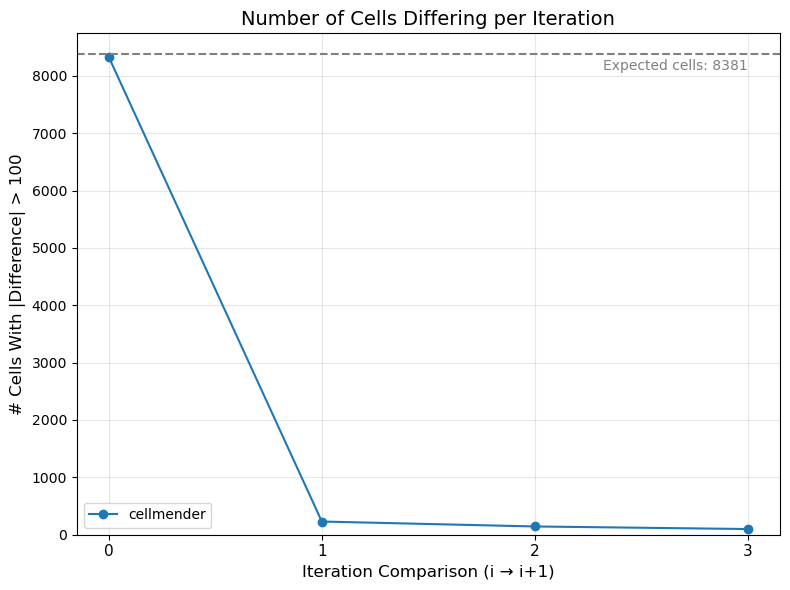

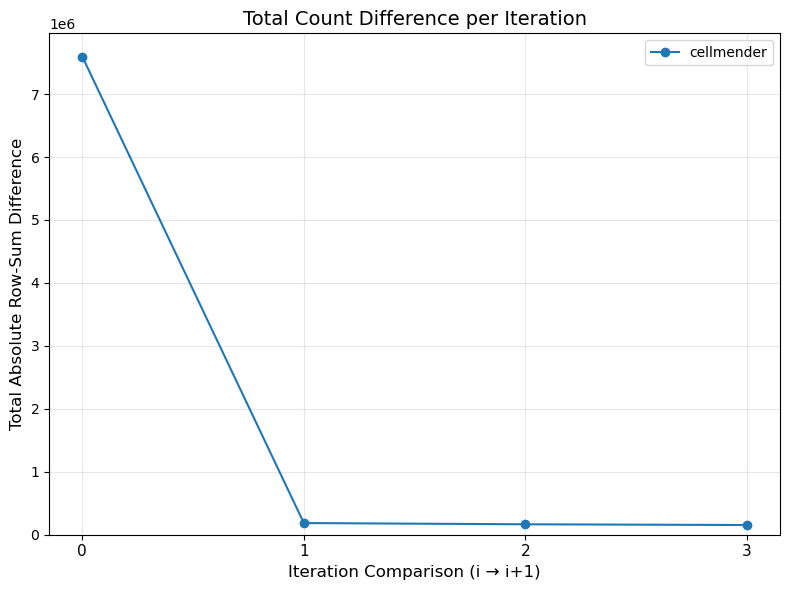

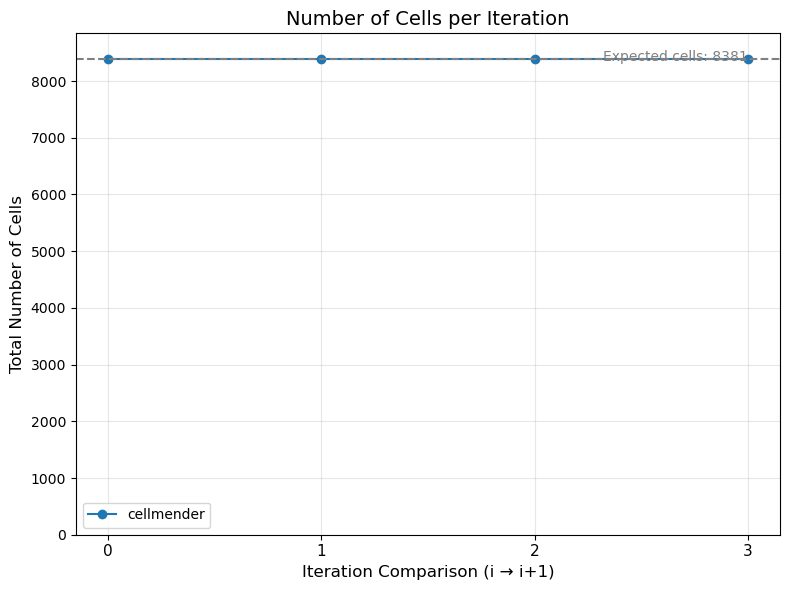

In [9]:
diff_counts = cm_utils.plot_iterative_difference_counts(adatas_dict, metric="cells", expected_cells=expected_cells, threshold=100, title="Number of Cells Differing per Iteration", out_path=os.path.join(out_dir, "diff_cells.png"))
diff_counts = cm_utils.plot_iterative_difference_counts(adatas_dict, metric="counts", title="Total Count Difference per Iteration", out_path=os.path.join(out_dir, "diff_counts.png"))
diff_counts = cm_utils.plot_iterative_difference_counts(adatas_dict, metric="number_of_cells", expected_cells=expected_cells, title="Number of Cells per Iteration", out_path=os.path.join(out_dir, "diff_number_of_cells.png"))

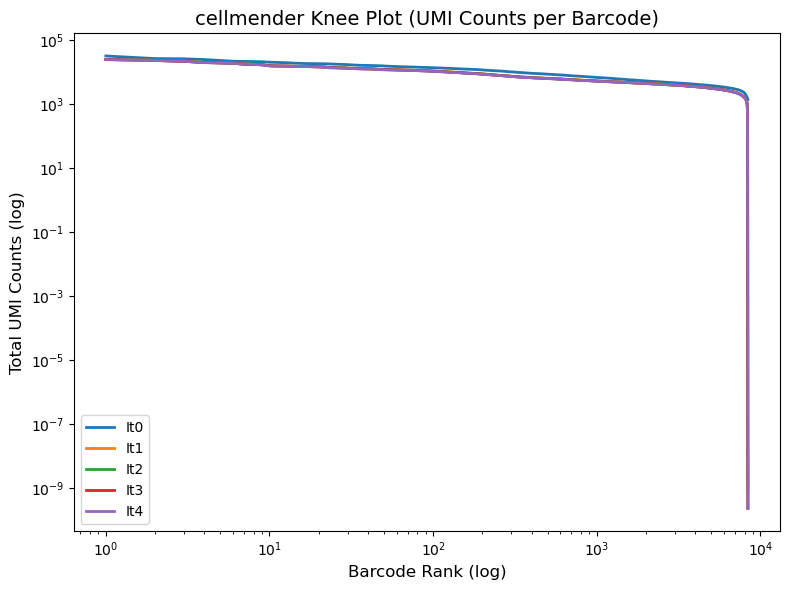

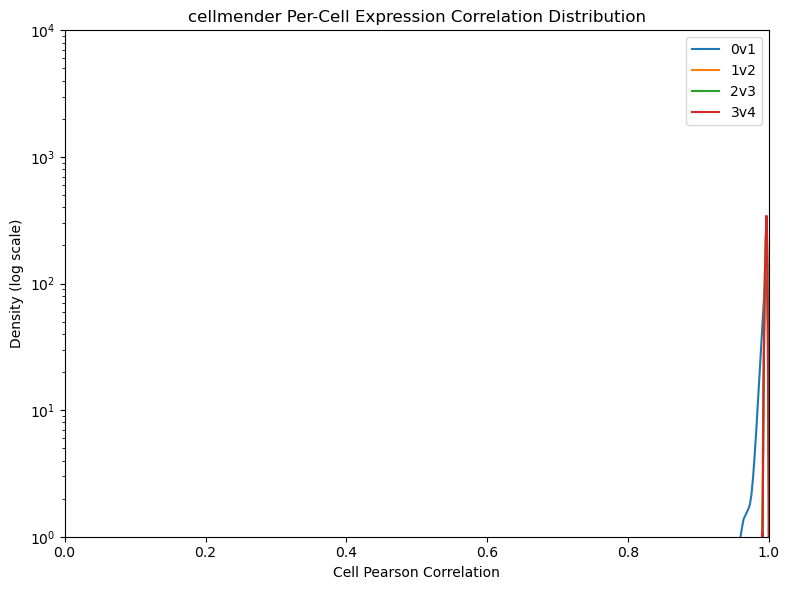

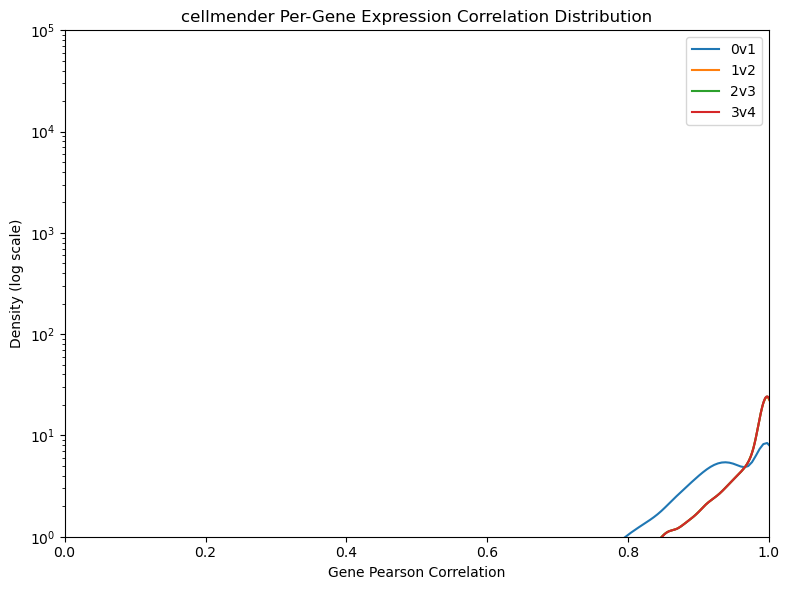

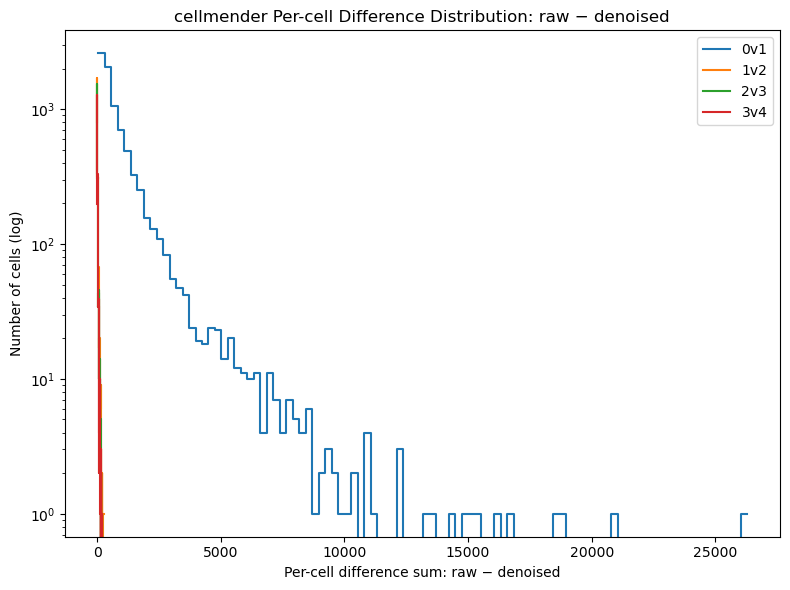

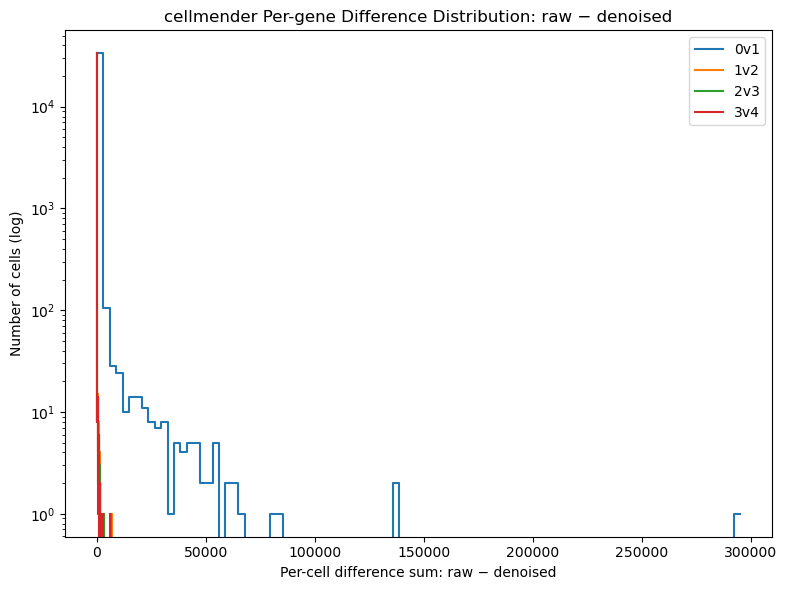

In [10]:
labels_knee = [f"It{i}" for i in range(iterations+1)]
labels_histograms = [f"{i}v{i+1}" for i in range(iterations)]
for tool in tools:
    cm_utils.plot_knee_multi(adatas_dict[tool], labels=labels_knee, title=f"{tool} Knee Plot (UMI Counts per Barcode)", filter_empty=True, out_path=os.path.join(out_dir, f"{tool}_knee_plot_overlay.png"))
    
    cm_utils.plot_per_cell_correlation_multi(adatas_dict[tool][:-1], adatas_dict[tool][1:], labels=labels_histograms, plot_type="cell", title=f"{tool} Per-Cell Expression Correlation Distribution", out_path=os.path.join(out_dir, f"{tool}_per_cell_correlation_overlay.png"))
    cm_utils.plot_per_cell_correlation_multi(adatas_dict[tool][:-1], adatas_dict[tool][1:], labels=labels_histograms, plot_type="gene", title=f"{tool} Per-Gene Expression Correlation Distribution", out_path=os.path.join(out_dir, f"{tool}_per_gene_correlation_overlay.png"))
    
    cm_utils.plot_per_cell_difference_multi(adata_raw_list=adatas_dict[tool][:-1], adata_denoised_list=adatas_dict[tool][1:], labels=labels_histograms, plot_type="cell", title=f"{tool} Per-cell Difference Distribution: raw − denoised", out_path=os.path.join(out_dir, f"{tool}_per_cell_absolute_difference_overlay.png"))
    cm_utils.plot_per_cell_difference_multi(adata_raw_list=adatas_dict[tool][:-1], adata_denoised_list=adatas_dict[tool][1:], labels=labels_histograms, plot_type="gene", title=f"{tool} Per-gene Difference Distribution: raw − denoised", out_path=os.path.join(out_dir, f"{tool}_per_gene_absolute_difference_overlay.png"))

In [11]:
# max_points = 10_000
# for i in range(1, iterations+1):
#     for tool in tools:
#         adatas_tool = adatas_dict[tool]
#         if len(adatas_tool) <= i:
#             continue
#         x_name = f"{tool} Iteration {i-1}" if i > 1 else "Raw expression"
#         y_name = f"{tool} Iteration {i}"

#         cm_utils.plot_matrix_scatterplot(adatas_tool[i-1], adatas_tool[i], scale="log", x_axis=x_name, y_axis=y_name, max_points=max_points, out_path=os.path.join(out_dir, f"{tool}_iteration{i}_expression_scatterplot_{max_points}points.png"), show=True)
#         cm_utils.plot_per_cell_correlation(adatas_tool[i-1], adatas_tool[i], title=f"Cell Pearson Correlation Histogram: {tool} Iteration {i}", out_path=os.path.join(out_dir, f"{tool}_iteration{i}_per_cell_correlation.png"))
#         cm_utils.plot_per_cell_difference(adatas_tool[i-1], adatas_tool[i], tool=tool, out_path=os.path.join(out_dir, f"{tool}_iteration{i}_per_cell_absolute_difference.png"))